**Goal:**
- Detect license plates from images or vehicle crops
- Visualize plate bounding boxes
- Save plate crops for downstream OCR
- Measure inference latency
- Produce reusable helper functions for source integration

In [2]:
import os
import sys
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [3]:
#  Add project root to sys.path for local imports
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [4]:
# Import local modules
from src.configs.settings import settings

In [20]:
# Inputs
IMAGES_DIR = settings.PLATE_INPUT_DIR / "images"
# FULL_FRAME_DIR = settings.IMAGE_SAMPLES_DIR

# Outputs
OUTPUT_DIR = settings.PLATE_OUTPUT_DIR / "images"
PLATE_CROPS_DIR = OUTPUT_DIR / "plate_crops"
# ANNOTATED_DIR = settings.PLATE_ANNOTATED_DIR

# Model
PLATE_MODEL_PATH = settings.models.plate_detector  
CONF_THRESHOLD = settings.thresholds.plate_conf

# Mode
RUN_ON_VEHICLE_CROPS = True
RUN_ON_FULL_FRAMES = False

In [6]:
# Load the plate detection model
plate_model = YOLO(PLATE_MODEL_PATH)

In [7]:
# Utility functions

# Convert BGR to RGB for visualization
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# load image 
def load_image(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    return image

# Clamp bounding box coordinates to image dimensions
def clamp_bbox(x1, y1, x2, y2, w, h):
    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(0, min(int(x2), w - 1))
    y2 = max(0, min(int(y2), h - 1))
    return x1, y1, x2, y2

# Crop the detected object using the bounding box
def crop_bbox(image, bbox):
    h, w = image.shape[:2]
    x1, y1, x2, y2 = clamp_bbox(*bbox, w, h)
    return image[y1:y2, x1:x2].copy()

# Draw bounding boxes and confidence scores on the image
def draw_plate_detections(image, detections, color=(255, 0, 0)):
    canvas = image.copy()
    for det in detections:
        x1, y1, x2, y2 = det["bbox"]
        conf = det["confidence"]
        label = f"plate: {conf:.2f}"

        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            canvas,
            label,
            (x1, max(25, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color,
            2
        )
    return canvas

# Sort detections by confidence score in descending order
def sort_detections_by_confidence(detections):
    return sorted(detections, key=lambda x: x["confidence"], reverse=True)

# Select the detection with the highest confidence score
def select_best_plate_detection(detections):
    if not detections:
        return None
    return sort_detections_by_confidence(detections)[0]

In [8]:
# Run plate detection on the input image and return detections and latency
def detect_plates(image, model, conf_threshold=0.25):
    start = time.perf_counter()
    results = model.predict(image, conf=conf_threshold, verbose=False)
    latency_ms = (time.perf_counter() - start) * 1000

    detections = []
    for result in results:
        for box in result.boxes:
            conf = float(box.conf[0].item())
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            detections.append({
                "confidence": conf,
                "bbox": (x1, y1, x2, y2)
            })

    detections = sort_detections_by_confidence(detections)
    return detections, latency_ms

In [9]:
# Refine the cropped plate image for better OCR performance
def refine_plate_crop(plate_crop, target_size=(320, 96), apply_equalization=True):
    """
    Simple production-friendly refinement for OCR preparation.
    More advanced deskew/perspective correction can be added later.
    """
    if plate_crop is None or plate_crop.size == 0:
        return None

    refined = plate_crop.copy()

    if apply_equalization:
        gray = cv2.cvtColor(refined, cv2.COLOR_BGR2GRAY)
        gray = cv2.equalizeHist(gray)
        refined = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    refined = cv2.resize(refined, target_size)
    return refined

In [10]:
# Load images from the specified directories
full_frame_images = []

if IMAGES_DIR.exists():
    # Recursively search all subdirectories for images
    vehicle_crop_images = list(IMAGES_DIR.rglob("*.jpg")) + \
                          list(IMAGES_DIR.rglob("*.png")) + \
                          list(IMAGES_DIR.rglob("*.jpeg"))

# if FULL_FRAME_DIR.exists():
#     full_frame_images = (
#         list(FULL_FRAME_DIR.glob("*.jpg")) +
#         list(FULL_FRAME_DIR.glob("*.png")) +
#         list(FULL_FRAME_DIR.glob("*.jpeg"))
#     )

print("Vehicle crop images found:", len(vehicle_crop_images))
# print("Full frame images found:", len(full_frame_images))

Vehicle crop images found: 4791


In [11]:
# Run plate detection on one image
image_path = vehicle_crop_images[4] # Change index as needed
image = load_image(image_path)  
detections, latency_ms = detect_plates(image, plate_model, CONF_THRESHOLD)

print("Latency (ms):", round(latency_ms, 2))
print("Detections:", detections)

Latency (ms): 406.69
Detections: [{'confidence': 0.9399277567863464, 'bbox': (239, 305, 355, 435)}]


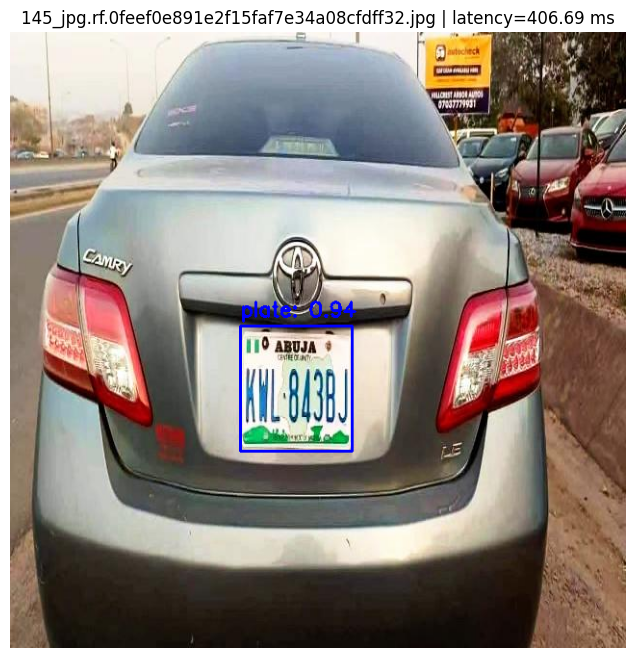

In [12]:
# Visualize detections

annotated = draw_plate_detections(image, detections)
plt.figure(figsize=(14, 8))
plt.imshow(bgr_to_rgb(annotated))
plt.title(f"{image_path.name} | latency={latency_ms:.2f} ms")
plt.axis("off")
plt.show()

In [13]:
# Select best detection and save crop

best_plate = select_best_plate_detection(detections)

saved_paths = []

if best_plate is not None:
    plate_crop = crop_bbox(image, best_plate["bbox"])
    refined_crop = refine_plate_crop(plate_crop)

    raw_crop_path = OUTPUT_DIR / f"{image_path.stem}_plate_raw.jpg"
    refined_crop_path = OUTPUT_DIR / f"{image_path.stem}_plate_refined.jpg"

    cv2.imwrite(str(raw_crop_path), plate_crop)
    cv2.imwrite(str(refined_crop_path), refined_crop)

    saved_paths.extend([raw_crop_path, refined_crop_path])

saved_paths

[WindowsPath('C:/Users/Samuel.Ozechi/Downloads/projects/vision-based-access-intelligence/data/plate_recognition/outputs/images/145_jpg.rf.0feef0e891e2f15faf7e34a08cfdff32_plate_raw.jpg'),
 WindowsPath('C:/Users/Samuel.Ozechi/Downloads/projects/vision-based-access-intelligence/data/plate_recognition/outputs/images/145_jpg.rf.0feef0e891e2f15faf7e34a08cfdff32_plate_refined.jpg')]

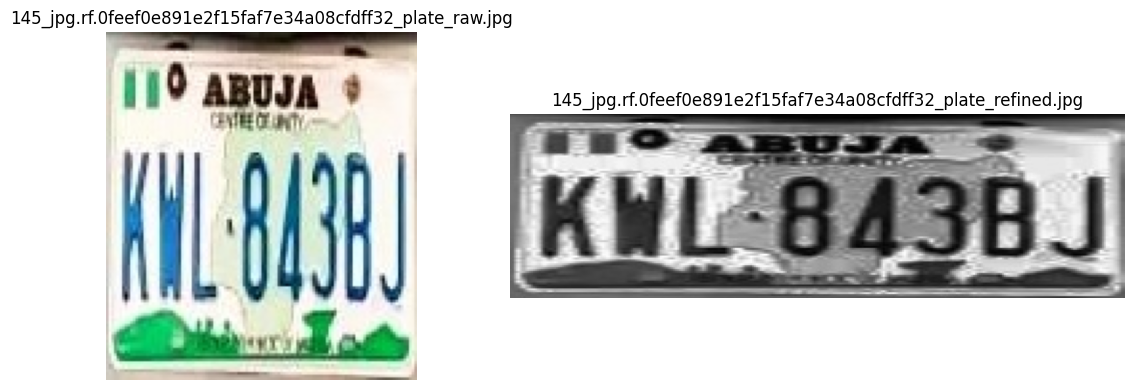

In [14]:
# Display saved plate crops

if saved_paths:
    fig, axes = plt.subplots(1, len(saved_paths), figsize=(12, 4))
    if len(saved_paths) == 1:
        axes = [axes]

    for ax, p in zip(axes, saved_paths):
        img = load_image(p)
        ax.imshow(bgr_to_rgb(img))
        ax.set_title(p.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No plate crop saved")

In [15]:
# # Save annotated sample image with detections drawn
# annotated_path = OUTPUT_DIR / f"{image_path.stem}_annotated.jpg"
# cv2.imwrite(str(annotated_path), annotated)
# print("Saved annotated image:", annotated_path)

In [21]:
# Batch inference function
def run_plate_detection_batch(image_paths, model, conf_threshold=0.25, save_best_crop=True):
    records = []

    for img_path in image_paths:
        image = load_image(img_path)
        detections, latency_ms = detect_plates(image, model, conf_threshold)

        best_det = select_best_plate_detection(detections)

        best_conf = None
        num_detections = len(detections)

        if best_det is not None:
            best_conf = best_det["confidence"]

            if save_best_crop:
                crop = crop_bbox(image, best_det["bbox"])
                refined = refine_plate_crop(crop)

                os.makedirs(PLATE_CROPS_DIR, exist_ok=True)
                # raw_out = OUTPUT_DIR / "plate_crops" / f"{img_path.stem}_plate_raw.jpg"
                refined_out = PLATE_CROPS_DIR / f"{img_path.stem}_plate_refined.jpg"

                # cv2.imwrite(str(raw_out), crop)
                cv2.imwrite(str(refined_out), refined)

        records.append({
            "image_name": img_path.name,
            "num_plate_detections": num_detections,
            "best_plate_confidence": round(best_conf, 4) if best_conf is not None else None,
            "latency_ms": round(latency_ms, 2),
        })

    return pd.DataFrame(records)

In [22]:
# Batch run on vehicle crops
if RUN_ON_VEHICLE_CROPS and vehicle_crop_images:
    plate_results_df = run_plate_detection_batch(
        vehicle_crop_images,
        plate_model,
        conf_threshold=CONF_THRESHOLD,
        save_best_crop=True
    )
    plate_results_df.head()
else:
    print("Vehicle crop mode disabled or no crop images found")

In [ ]:
# # Batch run on full frames
# if RUN_ON_FULL_FRAMES and full_frame_images:
#     full_frame_plate_results_df = run_plate_detection_batch(
#         full_frame_images,
#         plate_model,
#         conf_threshold=CONF_THRESHOLD,
#         save_best_crop=False
#     )
#     full_frame_plate_results_df.head()
# else:
#     print("Full-frame mode disabled or no full-frame images found")
    

In [ ]:
# Batch Summary
if RUN_ON_VEHICLE_CROPS and 'plate_results_df' in locals():
    print("Average latency (ms):", round(plate_results_df["latency_ms"].mean(), 2))
    print("Average detections:", round(plate_results_df["num_plate_detections"].mean(), 2))
    print("Detection success rate:",
          round((plate_results_df["num_plate_detections"] > 0).mean() * 100, 2), "%")

    plate_results_df.describe(include="all")

Average latency (ms): 67.03
Average detections: 1.0
Detection success rate: 99.98 %


In [ ]:
# Failure Review
if RUN_ON_VEHICLE_CROPS and 'plate_results_df' in locals():
    failed_plate_df = plate_results_df[plate_results_df["num_plate_detections"] == 0]
    failed_plate_df

In [ ]:
# # Save results to CSV
# if RUN_ON_VEHICLE_CROPS and 'plate_results_df' in locals():
#     csv_path = OUTPUT_DIR / "plate_detection_baseline_results.csv"
#     plate_results_df.to_csv(csv_path, index=False)
#     print("Saved:", csv_path)

In [ ]:
# Video Inference prototype
VIDEO_PATH = settings.VEHICLE_INPUT_DIR / "videos" / "sample_video.mp4"
VIDEO_OUTPUT = settings.PLATE_OUTPUT_DIR / "videos" / "plate_detection_demo.mp4"

In [ ]:
# Process video frame by frame, run plate detection, annotate, and save output video
cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(VIDEO_OUTPUT), fourcc, fps, (width, height))

frame_count = 0
latencies = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    detections, latency_ms = detect_plates(frame, plate_model, CONF_THRESHOLD)
    annotated = draw_plate_detections(frame, detections, color=(255, 0, 0))

    annotated = draw_plate_detections(annotated, detections, color=(255, 0, 0))

    writer.write(annotated)
    latencies.append(latency_ms)
    frame_count += 1

cap.release()
writer.release()

print("Processed frames:", frame_count)
print("Average latency (ms):", round(float(np.mean(latencies)), 2) if latencies else None)
print("Saved video:", VIDEO_OUTPUT)

Processed frames: 2600
Average latency (ms): 64.2
Saved video: C:\Users\Samuel.Ozechi\Downloads\projects\vision-based-access-intelligence\data\outputs\plate_detection_outputs\plate_detection_demo.mp4
